In [ ]:
%matplotlib inline


图像分类器
=====================

通常来说，当处理图像，文本，语音或者视频数据时，我们可以使用标准 python 包将数据加载成 numpy 数组格式，然后将这个数组转换成 torch.*Tensor

- 对于图像，可以用 Pillow，OpenCV
- 对于语音，可以用 scipy，librosa
- 对于文本，可以直接用 Python 或 Cython 基础数据加载模块，或者用 NLTK 和 SpaCy

考虑到这一点，为了给开发者提供更加方便的加载方式，PyTorch已经创建了一个叫做 totchvision 的包，该包含有支持加载类似Imagenet，CIFAR10，MNIST 等公共数据集的数据加载模块 torchvision.datasets 和支持加载图像数据数据转换模块 torch.utils.data.DataLoader。这提供了极大的便利，并且避免了编写“模板代码”。
    
对于本节我们将使用CIFAR10数据集，它包含十个类别：airplane、automobile、 bird、cat、deer、dog、frog、horse、ship、truck。CIFAR10中的图像尺寸为3*32*32，也就是RGB的3层颜色通道，图像的宽高都为32。


训练一个图像分类器
----------------------------


我们将按次序的做如下几步：
1.	使用torchvision加载并且归一化CIFAR10的训练和测试数据集
2.	定义一个卷积神经网络
3.	定义一个损失函数
4.	在训练样本数据上训练网络
5.	在测试样本数据上测试网络

使用 `torchvision`，用它来加载 CIFAR10 数据非常简单。



In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms

torchvision 数据集的输出是范围在[0,1]之间的 PILImage

我们将他们转换成归一化范围为[-1,1]之间的张量 Tensors。下面我们加载数据集：

如果是第一次下载数据集，出现进度条。

如果下载很慢，可以在[百度网盘](https://pan.baidu.com/s/1edVtY5ov0eL_X_1JpjByNg?pwd=ppb4 )下载好后，放到 `data/cifar-10-python.tar.gz`，再执行下面的命令

In [4]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=4,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

数据集下载完毕后，我们来展示一些训练图片看看:

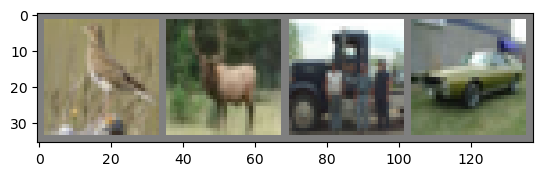

 bird  deer truck   car


In [6]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join('%5s' % classes[labels[j]] for j in range(4)))

### 定义卷积神经网络

我们可以从神经网络章节中，复制神经网络模块相关的代码，并修改它为3通道的图片（在此之前它被定义为1通道）




In [5]:
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()

### 定义损失和优化器

我们使用分类交叉熵Cross-Entropy 作损失函数，支持动量的SGD做为优化器。



In [6]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

### 训练网络

这里的事情就很简单了，我们只需要在数据迭代器上循环传给网络和优化器的输入就可以。



In [7]:
for epoch in range(2):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / 2000))
            running_loss = 0.0

print('Finished Training')

[1,  2000] loss: 2.245
[1,  4000] loss: 1.874
[1,  6000] loss: 1.685
[1,  8000] loss: 1.592
[1, 10000] loss: 1.538
[1, 12000] loss: 1.492
[2,  2000] loss: 1.433
[2,  4000] loss: 1.403
[2,  6000] loss: 1.370
[2,  8000] loss: 1.350
[2, 10000] loss: 1.321
[2, 12000] loss: 1.308
Finished Training


### 使用测试集评估

我们已经通过训练数据集对网络进行了2次训练，即两个epoch。
 
现在我们来检查一下，这个网络模型是否已经学到了东西。

我们将用神经网络的输出作为预测的类标来检查网络的预测性能，用样本的真实类标来校对。

如果预测是正确的，我们将样本添加到正确预测的列表里。



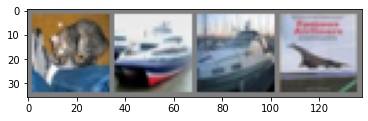

GroundTruth:    cat  ship  ship plane


In [9]:
dataiter = iter(testloader)
images, labels = dataiter.next()

# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join('%5s' % classes[labels[j]] for j in range(4)))

现在让我们看看，训练好的网络模型认为这些样本应该预测成什么：

In [10]:
outputs = net(images)

网络的最后一层是一个全连接层，输出的是预测的与十个类的近似程度，值越大则表示与某一个类的近似程度越高，网络就越认为图像是属于这一类别。所以让我们打印其中最相似类别类标：

In [11]:
_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join('%5s' % classes[predicted[j]]
                              for j in range(4)))

Predicted:    cat   car   car plane


从结果来看，效果非常好，接下来我们对测试集中的每一张图片都进行预测，并且计算整体的准确率。

In [12]:
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on the 10000 test images: %d %%' % (
    100 * correct / total))

Accuracy of the network on the 10000 test images: 53 %


如果模型是随机预测的话，那么准确率应该是10%，而我们的训练两个epoch得到的模型，准确率为53%。这说明网络还是学到了一些东西。为了进行精细化分析，下面我们看看模型在每一个类别上的准确率。

In [8]:
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        c = (predicted == labels).squeeze()
        for i in range(4):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1


for i in range(10):
    print('Accuracy of %5s : %2d %%' % (
        classes[i], 100 * class_correct[i] / class_total[i]))

Accuracy of plane : 56 %
Accuracy of   car : 66 %
Accuracy of  bird : 25 %
Accuracy of   cat :  7 %
Accuracy of  deer : 45 %
Accuracy of   dog : 65 %
Accuracy of  frog : 58 %
Accuracy of horse : 70 %
Accuracy of  ship : 69 %
Accuracy of truck : 70 %


### 使用GPU加速

在PyTorch中，如何将模型跑在GPU上呢？

很简单，就像把Tensor转移到GPU上一样，我们只需要把神经网络模块也转移到GPU上即可。

具体做法是，如果GPU能用（CUDA可用），则取得CUDA的设备标识。



In [9]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Assume that we are on a CUDA machine, then this should print a CUDA device:

print(device)

cpu


接着使用下面命令将神经网络模块移到CUDA设备上。

方法to会递归遍历网络中的所有模块，并将他们的参数（parameters）和缓存（buffers）转换为CUDA张量。

.. code:: python

    net.to(device)


需要注意的时，当网络移动到CUDA设备后，输入到网络中的张量也需要先移动到CUDA设备上。

因为PyTorch只能在同一个设备上做矩阵操作。

.. code:: python

        inputs, labels = inputs.to(device), labels.to(device)
